✅ 维生素C半衰期：34.7 天


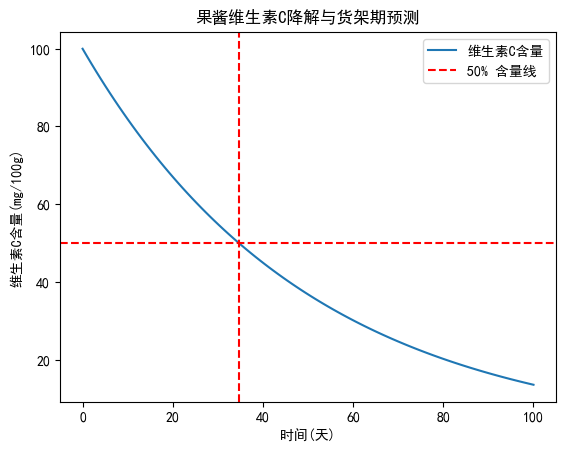

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 一级动力学模型：C = C0 * exp(-k*t)
C0 = 100  # 初始维生素C含量(mg/100g)
k = 0.02  # 降解速率常数(1/天)
t = np.linspace(0, 100, 100)  # 时间0-100天
C = C0 * np.exp(-k * t)

# 找到含量降到初始值50%的时间（半衰期≈货架期参考）
t_half = np.log(2)/k
print(f"✅ 维生素C半衰期：{t_half:.1f} 天")

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.plot(t, C, label="维生素C含量")
plt.axhline(y=50, color='r', linestyle='--', label="50% 含量线")
plt.axvline(x=t_half, color='r', linestyle='--')
plt.xlabel("时间(天)")
plt.ylabel("维生素C含量(mg/100g)")
plt.title("果酱维生素C降解与货架期预测")
plt.legend()
plt.show()

✅ GAB 模型参数：m0=0.431, C=0.87, K=0.79


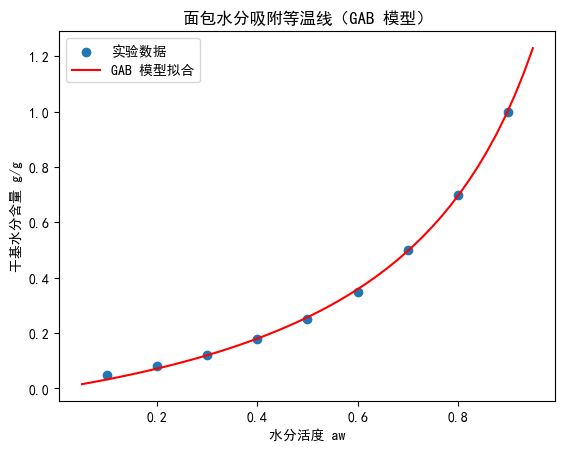

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# GAB 模型公式
def gab_model(aw, m0, C, K):
    return (m0 * C * K * aw) / ((1 - K*aw) * (1 - K*aw + C*K*aw))

# 模拟实验数据（水分活度 aw vs 干基水分含量 m）
aw_data = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
m_data = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.5, 0.7, 1.0])

# 拟合模型
popt, _ = curve_fit(gab_model, aw_data, m_data, p0=[0.2, 10, 0.5])
m0, C, K = popt
print(f"✅ GAB 模型参数：m0={m0:.3f}, C={C:.2f}, K={K:.2f}")

# 绘图
aw_fit = np.linspace(0.05, 0.95, 50)
m_fit = gab_model(aw_fit, *popt)

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.scatter(aw_data, m_data, label="实验数据")
plt.plot(aw_fit, m_fit, 'r-', label="GAB 模型拟合")
plt.xlabel("水分活度 aw")
plt.ylabel("干基水分含量 g/g")
plt.title("面包水分吸附等温线（GAB 模型）")
plt.legend()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2lab

# 模拟不同浓度茶汤的 RGB 颜色（浅黄→深黄→棕黄）
tea_colors = [
    (1.0, 0.95, 0.7),   # 淡茶汤
    (0.95, 0.8, 0.4),   # 中等茶汤
    (0.8, 0.5, 0.2)     # 浓茶汤
]

# 转换为 Lab 色空间
lab_colors = [rgb2lab(np.array(color)/255) for color in tea_colors]

print("✅ 茶汤 Lab 颜色值：")
for i, (L, a, b) in enumerate(lab_colors):
    print(f"浓度{i+1}：L={L:.1f}, a={a:.1f}, b={b:.1f}")

# 可视化颜色
plt.rcParams["font.sans-serif"] = ["SimHei"]
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
for i, color in enumerate(tea_colors):
    ax[i].set_facecolor(color)
    ax[i].set_title(f"浓度{i+1}")
    ax[i].axis("off")
plt.suptitle("不同浓度茶汤颜色模拟")
plt.show()

ImportError: cannot import name 'rgb2lab' from 'matplotlib.colors' (D:\Anaconda3\envs\food_safety\Lib\site-packages\matplotlib\colors.py)

✅ 预计腐败时间：6.7 天


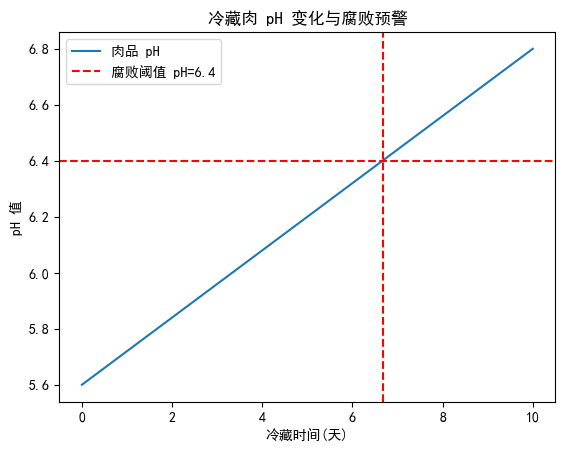

In [4]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 50)  # 0-10天
# 正常肉 pH≈5.6，腐败后上升到≥6.5
pH = 5.6 + 0.12 * t  # 线性增长模型

# 腐败阈值 pH=6.4
t_spoil = (6.4 - 5.6)/0.12
print(f"✅ 预计腐败时间：{t_spoil:.1f} 天")

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.plot(t, pH, label="肉品 pH")
plt.axhline(y=6.4, color='r', linestyle='--', label="腐败阈值 pH=6.4")
plt.axvline(x=t_spoil, color='r', linestyle='--')
plt.xlabel("冷藏时间(天)")
plt.ylabel("pH 值")
plt.title("冷藏肉 pH 变化与腐败预警")
plt.legend()
plt.show()

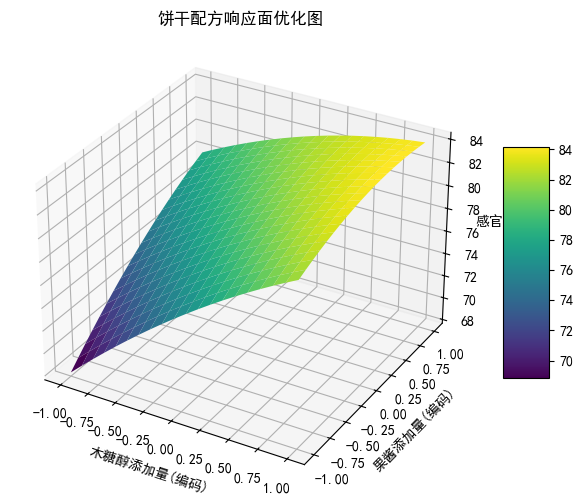

In [6]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 模拟响应面模型：总评分 = 80 + 5*A + 3*B - 2*A*B - A² - B²
A = np.linspace(-1, 1, 20)  # 木糖醇添加量（编码值）
B = np.linspace(-1, 1, 20)  # 果酱添加量（编码值）
A, B = np.meshgrid(A, B)
score = 80 + 5*A + 3*B - 2*A*B - A**2 - B**2

# 3D 绘图
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, score, cmap='viridis')

ax.set_xlabel("木糖醇添加量(编码)")
ax.set_ylabel("果酱添加量(编码)")
ax.set_zlabel("感官评分")
ax.set_title("饼干配方响应面优化图")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

✅ 茶汤 Lab 颜色分析结果：
浓度       L*(亮度)       a*(红绿色度)        b*(黄蓝色度)       
--------------------------------------------------
淡茶汤      95.22        -5.07           32.38          
中等茶汤     83.48        1.78            54.97          
浓茶汤      60.24        23.36           51.84          


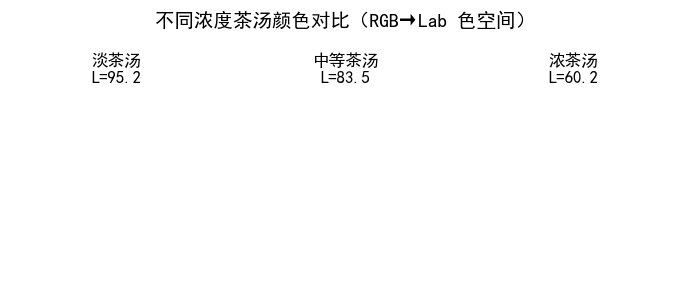

In [2]:
%matplotlib inline  
# 强制在 notebook 内显示图表
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab

# ---------------------- 1. 模拟不同浓度茶汤的 RGB 颜色 ----------------------
tea_colors = [
    (1.0, 0.95, 0.7),    # 淡茶汤（浅黄色）
    (0.95, 0.8, 0.4),    # 中等茶汤（深黄色）
    (0.8, 0.5, 0.2)      # 浓茶汤（棕黄色）
]
tea_names = ["淡茶汤", "中等茶汤", "浓茶汤"]

# ---------------------- 2. 转换为 Lab 色空间 ----------------------
lab_colors = [rgb2lab(np.array(color)) for color in tea_colors]

# ---------------------- 3. 打印 Lab 颜色值 ----------------------
print("✅ 茶汤 Lab 颜色分析结果：")
print(f"{'浓度':<8} {'L*(亮度)':<12} {'a*(红绿色度)':<15} {'b*(黄蓝色度)':<15}")
print("-" * 50)
for i, (L, a, b) in enumerate(lab_colors):
    print(f"{tea_names[i]:<8} {L:<12.2f} {a:<15.2f} {b:<15.2f}")

# ---------------------- 4. 可视化颜色对比 ----------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(1, 3, figsize=(7, 3))

for i, color in enumerate(tea_colors):
    ax[i].set_facecolor(color)
    ax[i].set_title(f"{tea_names[i]}\nL={lab_colors[i][0]:.1f}")
    ax[i].axis("off")

plt.suptitle("不同浓度茶汤颜色对比（RGB→Lab 色空间）", fontsize=14)
plt.tight_layout()
plt.show()